In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Charger le dataset Titanic
df = sns.load_dataset('titanic')

# Afficher les 5 premières lignes
print(df.head())

# Informations générales
print(df.info())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-nu

In [ ]:
df = df.drop(columns=['class', 'who', 'adult_male', 'deck', 'embark_town', 'alive'], errors='ignore')
print(df)

     survived  pclass     sex   age  sibsp  parch     fare embarked  alone
0           0       3    male  22.0      1      0   7.2500        S  False
1           1       1  female  38.0      1      0  71.2833        C  False
2           1       3  female  26.0      0      0   7.9250        S   True
3           1       1  female  35.0      1      0  53.1000        S  False
4           0       3    male  35.0      0      0   8.0500        S   True
..        ...     ...     ...   ...    ...    ...      ...      ...    ...
886         0       2    male  27.0      0      0  13.0000        S   True
887         1       1  female  19.0      0      0  30.0000        S   True
888         0       3  female   NaN      1      2  23.4500        S  False
889         1       1    male  26.0      0      0  30.0000        C   True
890         0       3    male  32.0      0      0   7.7500        Q   True

[891 rows x 9 columns]


In [ ]:
df['age'] = df['age'].fillna(df['age'].median())

In [ ]:
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

In [ ]:
print(df)

     survived  pclass     sex   age  sibsp  parch     fare embarked  alone
0           0       3    male  22.0      1      0   7.2500        S  False
1           1       1  female  38.0      1      0  71.2833        C  False
2           1       3  female  26.0      0      0   7.9250        S   True
3           1       1  female  35.0      1      0  53.1000        S  False
4           0       3    male  35.0      0      0   8.0500        S   True
..        ...     ...     ...   ...    ...    ...      ...      ...    ...
886         0       2    male  27.0      0      0  13.0000        S   True
887         1       1  female  19.0      0      0  30.0000        S   True
888         0       3  female  28.0      1      2  23.4500        S  False
889         1       1    male  26.0      0      0  30.0000        C   True
890         0       3    male  32.0      0      0   7.7500        Q   True

[891 rows x 9 columns]


In [ ]:
df['sex'] = df['sex'].map({'male': 0, 'female': 1})
print(df)

     survived  pclass  sex   age  sibsp  parch     fare embarked  alone
0           0       3    0  22.0      1      0   7.2500        S  False
1           1       1    1  38.0      1      0  71.2833        C  False
2           1       3    1  26.0      0      0   7.9250        S   True
3           1       1    1  35.0      1      0  53.1000        S  False
4           0       3    0  35.0      0      0   8.0500        S   True
..        ...     ...  ...   ...    ...    ...      ...      ...    ...
886         0       2    0  27.0      0      0  13.0000        S   True
887         1       1    1  19.0      0      0  30.0000        S   True
888         0       3    1  28.0      1      2  23.4500        S  False
889         1       1    0  26.0      0      0  30.0000        C   True
890         0       3    0  32.0      0      0   7.7500        Q   True

[891 rows x 9 columns]


In [ ]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(drop='first', sparse_output=False)

encoded = encoder.fit_transform(df[['embarked']])

encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(['embarked']))

# Fusionner
df = pd.concat([df, encoded_df], axis=1)

# Supprimer ancienne colonne
df.drop(columns=['embarked'], inplace=True)

In [ ]:
df

,survived,pclass,sex,age,sibsp,parch,fare,alone,embarked_Q,embarked_S
0,0,3,0,22.0,1,0,7.2500,False,0.0,1.0
1,1,1,1,38.0,1,0,71.2833,False,0.0,0.0
2,1,3,1,26.0,0,0,7.9250,True,0.0,1.0
3,1,1,1,35.0,1,0,53.1000,False,0.0,1.0
4,0,3,0,35.0,0,0,8.0500,True,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...
886,0,2,0,27.0,0,0,13.0000,True,0.0,1.0
887,1,1,1,19.0,0,0,30.0000,True,0.0,1.0
888,0,3,1,28.0,1,2,23.4500,False,0.0,1.0
889,1,1,0,26.0,0,0,30.0000,True,0.0,0.0


In [ ]:
from sklearn.model_selection import train_test_split

# Variable cible
y = df['survived']

# Variables explicatives
X = df.drop(columns=['survived'])

# Division des données
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Taille X_train :", X_train.shape)
print("Taille X_test :", X_test.shape)

Taille X_train : (712, 9)
Taille X_test : (179, 9)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Apprendre + transformer sur train
X_train_scaled = scaler.fit_transform(X_train)

# Transformer seulement sur test
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

# Création du modèle
model = LogisticRegression()

# Entraînement
model.fit(X_train_scaled, y_train)

LogisticRegression()

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = model.predict(X_test_scaled)

In [ ]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[89 16]
 [20 54]]


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.85      0.83       105
           1       0.77      0.73      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



In [ ]:
y_proba = model.predict_proba(X_test_scaled)[:, 1]

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

print("AUC :", auc)

AUC : 0.8868725868725867


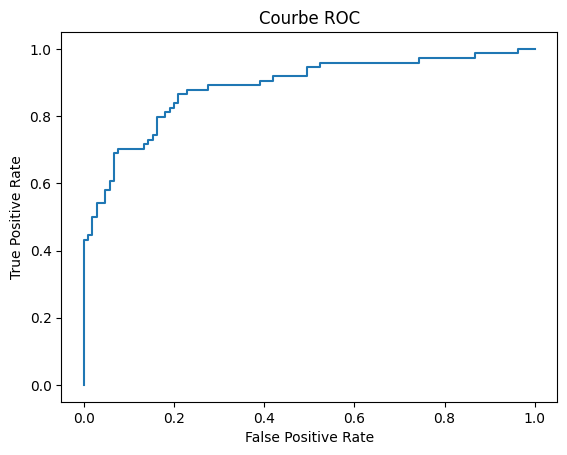

In [ ]:
import matplotlib.pyplot as plt

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Courbe ROC")
plt.show()

In [ ]:
coefficients = model.coef_[0]

In [ ]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': coefficients
})

coef_df = coef_df.sort_values(by='Coefficient', ascending=False)

print(coef_df)

      Feature  Coefficient
1         sex     1.247654
5        fare     0.110822
7  embarked_Q    -0.024204
8  embarked_S    -0.158686
4       parch    -0.212448
6       alone    -0.333565
2         age    -0.386208
3       sibsp    -0.546144
0      pclass    -0.745569
